# Unità 4 — Confronto BB84 vs E91

In questo notebook confrontiamo i protocolli BB84 ed E91 usando le simulazioni già costruite. Il confronto considera metriche comuni come lunghezza della chiave sifted, key rate, QBER e accettazione della chiave rispetto a una soglia QBER. Per E91 viene richiamato anche il test CHSH come verifica delle correlazioni quantistiche.

## Setup e import

Prepariamo il percorso del progetto in modo da poter importare le funzioni dalla cartella `src`, anche quando il notebook viene eseguito dalla cartella `notebooks`.

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "bb84.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "bb84.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from bb84 import (
    run_bb84_protocol,
    run_bb84_protocol_with_eve,
    sift_keys as sift_keys_bb84,
    compute_qber as compute_qber_bb84,
)

from e91 import (
    run_e91_protocol,
    run_e91_protocol_with_eve,
    run_chsh_experiment,
    run_chsh_experiment_with_eve,
    sift_keys as sift_keys_e91,
    compute_qber as compute_qber_e91,
)

from metrics import summarize_qkd_results


## Obiettivo del confronto

BB84 ed E91 sono protocolli QKD diversi. BB84 è un protocollo prepare-and-measure, mentre E91 è entanglement-based. Nel caso BB84 con Eve osserviamo l'effetto dell'attacco intercept-resend sul QBER. Nel caso E91, oltre al QBER ideale, possiamo richiamare il test CHSH per verificare la natura quantistica delle correlazioni.

## Parametri comuni

Usiamo lo stesso numero di round, la stessa soglia operativa di QBER e gli stessi seed di riferimento per rendere il confronto pi? ordinato.

`qber_threshold` ? la soglia semplificata per accettare o rifiutare la chiave in base al QBER. `chsh_security_threshold` ? una soglia operativa didattica per distinguere una violazione CHSH robusta da una violazione appena sopra il limite classico.


In [3]:
n_rounds = 1000
qber_threshold = 0.11
chsh_security_threshold = 2.2
seed = 123
shots_chsh = 2000


## Scenario 1 — BB84 ideale

Nel caso ideale non ci sono Eve, rumore o decoerenza. Dopo il sifting, Alice e Bob dovrebbero ottenere la stessa chiave.

In [4]:
results_bb84_ideal = run_bb84_protocol(n_rounds=n_rounds, seed=seed)
alice_key_bb84_ideal, bob_key_bb84_ideal = sift_keys_bb84(results_bb84_ideal)
qber_bb84_ideal = compute_qber_bb84(alice_key_bb84_ideal, bob_key_bb84_ideal)

summary_bb84_ideal = summarize_qkd_results(
    protocol_name="BB84 ideale",
    results=results_bb84_ideal,
    alice_key=alice_key_bb84_ideal,
    bob_key=bob_key_bb84_ideal,
    qber=qber_bb84_ideal,
    qber_threshold=qber_threshold,
)

print(summary_bb84_ideal)

{'protocol': 'BB84 ideale', 'n_rounds': 1000, 'kept_rounds': 524, 'discarded_rounds': 476, 'sifted_key_length': 524, 'sifted_key_rate': 0.524, 'qber': 0.0, 'qber_threshold': 0.11, 'accepted': True}


## Scenario 2 — BB84 con Eve intercept-resend

Qui Eve intercetta sempre, cioè `intercept_probability = 1.0`. Questo scenario serve a mostrare l'impatto massimo dell'attacco intercept-resend sul QBER.

In [5]:
results_bb84_eve = run_bb84_protocol_with_eve(
    n_rounds=n_rounds,
    intercept_probability=1.0,
    seed=seed,
)
alice_key_bb84_eve, bob_key_bb84_eve = sift_keys_bb84(results_bb84_eve)
qber_bb84_eve = compute_qber_bb84(alice_key_bb84_eve, bob_key_bb84_eve)

summary_bb84_eve = summarize_qkd_results(
    protocol_name="BB84 con Eve",
    results=results_bb84_eve,
    alice_key=alice_key_bb84_eve,
    bob_key=bob_key_bb84_eve,
    qber=qber_bb84_eve,
    qber_threshold=qber_threshold,
)

print(summary_bb84_eve)

{'protocol': 'BB84 con Eve', 'n_rounds': 1000, 'kept_rounds': 524, 'discarded_rounds': 476, 'sifted_key_length': 524, 'sifted_key_rate': 0.524, 'qber': 0.25, 'qber_threshold': 0.11, 'accepted': False}


## Scenario 3 — E91 ideale

E91 ideale usa coppie entangled e, in assenza di rumore o attacchi, produce QBER nullo sui round mantenuti.

In [6]:
results_e91_ideal = run_e91_protocol(n_rounds=n_rounds, seed=seed)
alice_key_e91_ideal, bob_key_e91_ideal = sift_keys_e91(results_e91_ideal)
qber_e91_ideal = compute_qber_e91(alice_key_e91_ideal, bob_key_e91_ideal)

summary_e91_ideal = summarize_qkd_results(
    protocol_name="E91 ideale",
    results=results_e91_ideal,
    alice_key=alice_key_e91_ideal,
    bob_key=bob_key_e91_ideal,
    qber=qber_e91_ideal,
    qber_threshold=qber_threshold,
)

print(summary_e91_ideal)

{'protocol': 'E91 ideale', 'n_rounds': 1000, 'kept_rounds': 502, 'discarded_rounds': 498, 'sifted_key_length': 502, 'sifted_key_rate': 0.502, 'qber': 0.0, 'qber_threshold': 0.11, 'accepted': True}


## Scenario 4 ? E91 con Eve intercept-resend

In questo scenario Eve intercetta il qubit entangled destinato a Bob, lo misura in una base casuale e reinvia un nuovo qubit coerente con il risultato ottenuto. Questa operazione rompe l?entanglement originario e pu? aumentare il QBER osservato dopo il sifting.


In [7]:
results_e91_eve = run_e91_protocol_with_eve(
    n_rounds=n_rounds,
    intercept_probability=1.0,
    seed=seed,
)

alice_key_e91_eve, bob_key_e91_eve = sift_keys_e91(results_e91_eve)
qber_e91_eve = compute_qber_e91(alice_key_e91_eve, bob_key_e91_eve)

summary_e91_eve = summarize_qkd_results(
    protocol_name="E91 con Eve",
    results=results_e91_eve,
    alice_key=alice_key_e91_eve,
    bob_key=bob_key_e91_eve,
    qber=qber_e91_eve,
    qber_threshold=qber_threshold,
)

summary_e91_eve


{'protocol': 'E91 con Eve',
 'n_rounds': 1000,
 'kept_rounds': 502,
 'discarded_rounds': 498,
 'sifted_key_length': 502,
 'sifted_key_rate': 0.502,
 'qber': 0.26693227091633465,
 'qber_threshold': 0.11,
 'accepted': False}

## Verifica CHSH per E91

CHSH non è una metrica di lunghezza della chiave, ma serve a mostrare che le correlazioni generate dallo stato entangled violano il limite classico.

In [8]:
import numpy as np

chsh_result = run_chsh_experiment(
    shots=shots_chsh,
    seed=seed,
)

classical_limit = 2
quantum_limit = 2 * np.sqrt(2)
abs_S_ideal = abs(chsh_result["S"])

chsh_result["abs_S"] = abs_S_ideal
chsh_result["classical_limit"] = classical_limit
chsh_result["quantum_limit"] = quantum_limit
chsh_result["violates_chsh"] = abs_S_ideal > classical_limit

if chsh_result["violates_chsh"]:
    print("Il valore ottenuto viola il limite classico |S| <= 2.")
else:
    print("Il valore ottenuto non viola il limite classico.")

print("Valore teorico massimo quantistico 2?2:", quantum_limit)
print("|S| ideale:", abs_S_ideal)

if abs_S_ideal > quantum_limit:
    print("Il valore stimato ? leggermente superiore a 2?2 per fluttuazioni statistiche dovute al numero finito di shot.")
else:
    print("Il valore stimato ? compatibile con il limite quantistico ideale.")


Il valore ottenuto viola il limite classico |S| <= 2.
Valore teorico massimo quantistico 2?2: 2.8284271247461903
|S| ideale: 2.8329999999999997
Il valore stimato ? leggermente superiore a 2?2 per fluttuazioni statistiche dovute al numero finito di shot.


## CHSH con Eve

In E91 l?attacco pu? essere osservato anche tramite la degradazione del parametro CHSH. Se Eve rompe l?entanglement, |S| tende a diminuire rispetto al caso ideale.


In [9]:
chsh_eve = run_chsh_experiment_with_eve(
    intercept_probability=1.0,
    shots=shots_chsh,
    seed=seed,
)

chsh_eve


{'E_ab': 0.372,
 'E_ab_prime': 0.345,
 'E_a_prime_b': 0.398,
 'E_a_prime_b_prime': -0.328,
 'S': 1.443,
 'abs_S': 1.443,
 'classical_limit': 2,
 'quantum_limit': np.float64(2.8284271247461903),
 'violates_chsh': False,
 'intercept_probability': 1.0,
 'shots': 2000}

In [10]:
abs_S_ideal = abs(chsh_result["S"])
abs_S_eve = abs(chsh_eve["S"])

print("|S| ideale:", abs_S_ideal)
print("|S| con Eve:", abs_S_eve)

if abs_S_eve < abs_S_ideal:
    print("L'attacco di Eve ha ridotto il parametro CHSH.")
else:
    print("In questa simulazione non si osserva una riduzione di |S|.")


|S| ideale: 2.8329999999999997
|S| con Eve: 1.443
L'attacco di Eve ha ridotto il parametro CHSH.


## Tabella comparativa

Raccogliamo i quattro scenari in una sola tabella pandas. La tabella serve solo per la rappresentazione finale dei risultati e distingue la decisione basata sul QBER dalla decisione finale, che per E91 considera anche CHSH.


In [11]:
comparison_results = []

accepted_by_qber_bb84_ideal = summary_bb84_ideal["accepted"]
comparison_results.append({
    "protocol": "BB84",
    "scenario": "BB84 ideale",
    "n_rounds": summary_bb84_ideal["n_rounds"],
    "sifted_key_length": summary_bb84_ideal["sifted_key_length"],
    "sifted_key_rate": summary_bb84_ideal["sifted_key_rate"],
    "qber": summary_bb84_ideal["qber"],
    "qber_threshold": qber_threshold,
    "accepted_by_qber": accepted_by_qber_bb84_ideal,
    "abs_S": None,
    "violates_chsh": None,
    "chsh_security_threshold": None,
    "accepted_by_chsh_threshold": None,
    "accepted_final": accepted_by_qber_bb84_ideal,
})

accepted_by_qber_bb84_eve = summary_bb84_eve["accepted"]
comparison_results.append({
    "protocol": "BB84",
    "scenario": "BB84 con Eve",
    "n_rounds": summary_bb84_eve["n_rounds"],
    "sifted_key_length": summary_bb84_eve["sifted_key_length"],
    "sifted_key_rate": summary_bb84_eve["sifted_key_rate"],
    "qber": summary_bb84_eve["qber"],
    "qber_threshold": qber_threshold,
    "accepted_by_qber": accepted_by_qber_bb84_eve,
    "abs_S": None,
    "violates_chsh": None,
    "chsh_security_threshold": None,
    "accepted_by_chsh_threshold": None,
    "accepted_final": accepted_by_qber_bb84_eve,
})

accepted_by_qber_e91_ideal = summary_e91_ideal["accepted"]
accepted_by_chsh_e91_ideal = abs(chsh_result["S"]) >= chsh_security_threshold
comparison_results.append({
    "protocol": "E91",
    "scenario": "E91 ideale",
    "n_rounds": summary_e91_ideal["n_rounds"],
    "sifted_key_length": summary_e91_ideal["sifted_key_length"],
    "sifted_key_rate": summary_e91_ideal["sifted_key_rate"],
    "qber": summary_e91_ideal["qber"],
    "qber_threshold": qber_threshold,
    "accepted_by_qber": accepted_by_qber_e91_ideal,
    "abs_S": abs(chsh_result["S"]),
    "violates_chsh": chsh_result["violates_chsh"],
    "chsh_security_threshold": chsh_security_threshold,
    "accepted_by_chsh_threshold": accepted_by_chsh_e91_ideal,
    "accepted_final": accepted_by_qber_e91_ideal and accepted_by_chsh_e91_ideal,
})

accepted_by_qber_e91_eve = summary_e91_eve["accepted"]
accepted_by_chsh_e91_eve = abs(chsh_eve["S"]) >= chsh_security_threshold
comparison_results.append({
    "protocol": "E91",
    "scenario": "E91 con Eve",
    "n_rounds": summary_e91_eve["n_rounds"],
    "sifted_key_length": summary_e91_eve["sifted_key_length"],
    "sifted_key_rate": summary_e91_eve["sifted_key_rate"],
    "qber": summary_e91_eve["qber"],
    "qber_threshold": qber_threshold,
    "accepted_by_qber": accepted_by_qber_e91_eve,
    "abs_S": abs(chsh_eve["S"]),
    "violates_chsh": chsh_eve["violates_chsh"],
    "chsh_security_threshold": chsh_security_threshold,
    "accepted_by_chsh_threshold": accepted_by_chsh_e91_eve,
    "accepted_final": accepted_by_qber_e91_eve and accepted_by_chsh_e91_eve,
})

comparison_df = pd.DataFrame(comparison_results)
comparison_df


,protocol,scenario,n_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted_by_qber,abs_S,violates_chsh,chsh_security_threshold,accepted_by_chsh_threshold,accepted_final
0,BB84,BB84 ideale,1000,524,0.524,0.000000,0.11,True,NaN,None,NaN,None,True
1,BB84,BB84 con Eve,1000,524,0.524,0.250000,0.11,False,NaN,None,NaN,None,False
2,E91,E91 ideale,1000,502,0.502,0.000000,0.11,True,2.833,True,2.2,True,True
3,E91,E91 con Eve,1000,502,0.502,0.266932,0.11,False,1.443,False,2.2,False,False


## Commento sulla tabella

BB84 viene valutato principalmente tramite QBER, perch? nel modello implementato il disturbo dell?attacco intercept-resend emerge come aumento degli errori nella chiave sifted.

E91 viene valutato tramite QBER e CHSH. Nel caso E91 con Eve ci aspettiamo sia un aumento del QBER sia una riduzione di |S|, perch? la misura di Eve rompe l?entanglement originario. CHSH non deve essere interpretato solo come booleano: una violazione appena sopra 2 pu? essere sospetta se non supera una soglia operativa pi? prudente.

La colonna `accepted_final` ? una decisione semplificata del progetto: per BB84 coincide con l?accettazione basata sul QBER, mentre per E91 richiede sia QBER accettabile sia |S| sufficientemente robusto.


## Grafico semplice — QBER

Visualizziamo il QBER dei tre scenari e aggiungiamo la soglia operativa scelta.

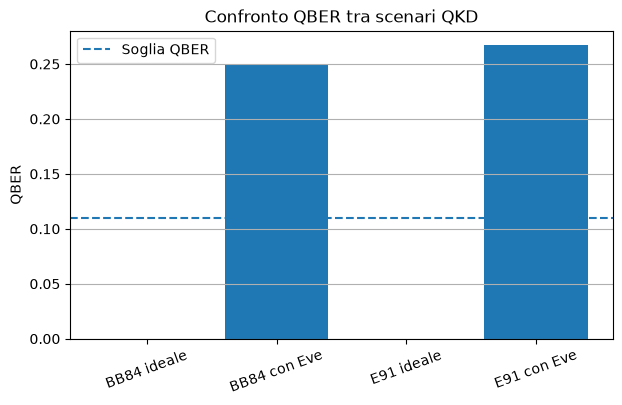

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["scenario"], comparison_df["qber"])
plt.axhline(qber_threshold, linestyle="--", label="Soglia QBER")
plt.ylabel("QBER")
plt.title("Confronto QBER tra scenari QKD")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()
plt.show()


## Grafico semplice — Sifted key rate

Visualizziamo la frazione di round che diventa chiave dopo il sifting.

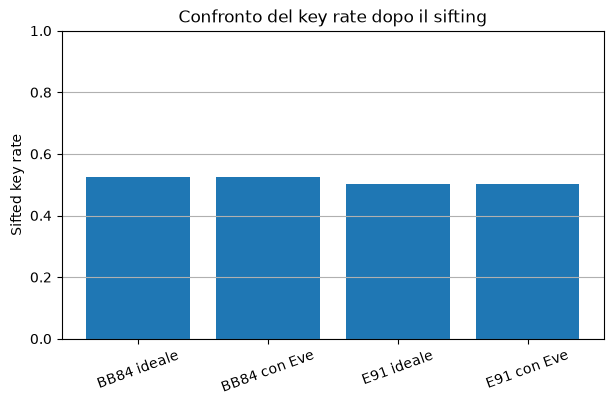

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["scenario"], comparison_df["sifted_key_rate"])
plt.ylabel("Sifted key rate")
plt.title("Confronto del key rate dopo il sifting")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.ylim(0, 1)
plt.show()


## Grafico semplice ? CHSH per E91

Per E91 aggiungiamo un grafico separato del parametro |S|, confrontando il caso ideale con il caso in presenza di Eve.


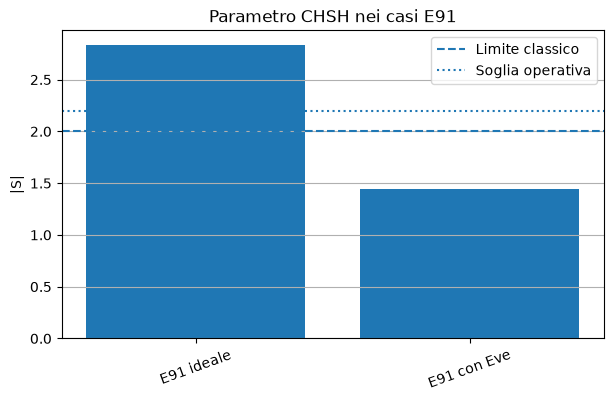

In [14]:
chsh_comparison_df = comparison_df[comparison_df["abs_S"].notna()]

plt.figure(figsize=(7, 4))
plt.bar(chsh_comparison_df["scenario"], chsh_comparison_df["abs_S"])
plt.axhline(2, linestyle="--", label="Limite classico")
plt.axhline(chsh_security_threshold, linestyle=":", label="Soglia operativa")
plt.ylabel("|S|")
plt.title("Parametro CHSH nei casi E91")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()
plt.show()


## Discussione qualitativa

Robustezza: BB84 ? sensibile all?attacco intercept-resend, che aumenta il QBER. E91 mostra lo stesso tipo di disturbo sulla chiave sifted, ma permette anche di osservare la degradazione delle correlazioni tramite CHSH.

Sicurezza: BB84 rileva Eve principalmente tramite QBER. E91 collega la sicurezza all?entanglement e alla violazione CHSH, quindi offre una diagnosi pi? ricca: non basta sapere se |S| supera 2, ma bisogna valutare quanto sia robusta la violazione.

Costo sperimentale: BB84 ? pi? semplice da implementare sperimentalmente. E91 richiede sorgenti entangled e misure correlate, quindi ? pi? esigente.

Scalabilit?: in questa fase il confronto resta simulativo. Rumore, decoerenza e modelli di distanza richiedono analisi separate.


## Commento finale

Questo notebook organizza i risultati gi? prodotti e aggiorna il confronto includendo E91 con Eve e CHSH con Eve. La decisione finale resta didattica: serve a confrontare i protocolli in modo ordinato, ma non sostituisce una pipeline completa di riconciliazione dell?informazione e privacy amplification.


## Esperimenti ripetuti e stabilit? statistica

I protocolli simulati sono probabilistici. Per questo una singola esecuzione non basta a descrivere completamente il comportamento del protocollo. In questa sezione ripetiamo gli esperimenti con seed diversi e osserviamo media e variabilit? delle metriche principali.

Per gli esperimenti ripetuti consideriamo solo QBER e sifted key rate. Il controllo CHSH ? mantenuto nella sezione dedicata, perch? ripeterlo per molti seed sarebbe pi? pesante dal punto di vista computazionale.


In [15]:
n_experiments = 20
n_rounds_repeated = 1000
qber_threshold_repeated = 0.11
base_seed = 1000

In [16]:
repeated_results = []

for i in range(n_experiments):
    current_seed = base_seed + i

    # BB84 ideale
    results = run_bb84_protocol(
        n_rounds=n_rounds_repeated,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_bb84(results)
    qber = compute_qber_bb84(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 ideale",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    summary["accepted_by_qber"] = summary["accepted"]
    repeated_results.append(summary)

    # BB84 con Eve
    results = run_bb84_protocol_with_eve(
        n_rounds=n_rounds_repeated,
        intercept_probability=1.0,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_bb84(results)
    qber = compute_qber_bb84(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 con Eve",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    summary["accepted_by_qber"] = summary["accepted"]
    repeated_results.append(summary)

    # E91 ideale
    results = run_e91_protocol(
        n_rounds=n_rounds_repeated,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_e91(results)
    qber = compute_qber_e91(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="E91 ideale",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    summary["accepted_by_qber"] = summary["accepted"]
    repeated_results.append(summary)

    # E91 con Eve
    results = run_e91_protocol_with_eve(
        n_rounds=n_rounds_repeated,
        intercept_probability=1.0,
        seed=current_seed,
    )
    alice_key, bob_key = sift_keys_e91(results)
    qber = compute_qber_e91(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="E91 con Eve",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_repeated,
    )
    summary["experiment"] = i + 1
    summary["accepted_by_qber"] = summary["accepted"]
    repeated_results.append(summary)

repeated_df = pd.DataFrame(repeated_results)
repeated_df.head(10)


,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,experiment,accepted_by_qber
0,BB84 ideale,1000,502,498,502,0.502,0.000000,0.11,True,1,True
1,BB84 con Eve,1000,502,498,502,0.502,0.245020,0.11,False,1,False
2,E91 ideale,1000,515,485,515,0.515,0.000000,0.11,True,1,True
3,E91 con Eve,1000,515,485,515,0.515,0.275728,0.11,False,1,False
4,BB84 ideale,1000,492,508,492,0.492,0.000000,0.11,True,2,True
5,BB84 con Eve,1000,492,508,492,0.492,0.245935,0.11,False,2,False
6,E91 ideale,1000,502,498,502,0.502,0.000000,0.11,True,2,True
7,E91 con Eve,1000,502,498,502,0.502,0.254980,0.11,False,2,False
8,BB84 ideale,1000,492,508,492,0.492,0.000000,0.11,True,3,True
9,BB84 con Eve,1000,492,508,492,0.492,0.252033,0.11,False,3,False


La tabella contiene una riga per ogni esperimento e per ogni protocollo. In questo modo possiamo osservare sia il comportamento dei singoli run sia la variabilità dovuta alla scelta del seed.

In [17]:
summary_stats = repeated_df.groupby("protocol").agg({
    "qber": ["mean", "std"],
    "sifted_key_rate": ["mean", "std"],
    "sifted_key_length": ["mean", "std"],
    "accepted_by_qber": "mean",
})

summary_stats


qber           sifted_key_rate           sifted_key_length  \
                  mean       std            mean       std              mean   
protocol                                                                       
BB84 con Eve  0.250241  0.013485         0.49675  0.013984            496.75   
BB84 ideale   0.000000  0.000000         0.49675  0.013984            496.75   
E91 con Eve   0.251621  0.019680         0.49810  0.014393            498.10   
E91 ideale    0.000000  0.000000         0.49810  0.014393            498.10   

                        accepted_by_qber  
                    std             mean  
protocol                                  
BB84 con Eve  13.984484              0.0  
BB84 ideale   13.984484              1.0  
E91 con Eve   14.392615              0.0  
E91 ideale    14.392615              1.0

BB84 ideale ed E91 ideale dovrebbero avere QBER medio nullo. BB84 con Eve ed E91 con Eve dovrebbero mostrare un QBER medio pi? alto. Il valore medio di `accepted_by_qber` indica la frazione di simulazioni in cui la chiave ? stata accettata rispetto alla soglia QBER scelta. La deviazione standard misura invece la stabilit? delle metriche su seed diversi.


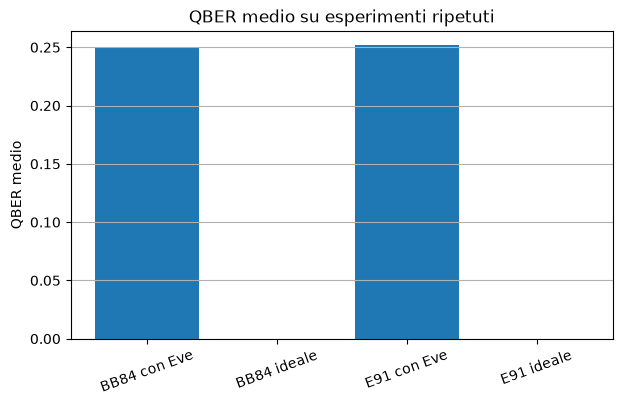

In [18]:
qber_mean = repeated_df.groupby("protocol")["qber"].mean()

plt.figure(figsize=(7, 4))
plt.bar(qber_mean.index, qber_mean.values)
plt.ylabel("QBER medio")
plt.title("QBER medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

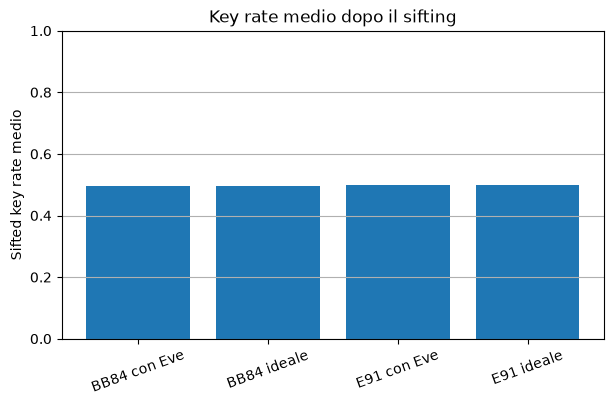

In [19]:
key_rate_mean = repeated_df.groupby("protocol")["sifted_key_rate"].mean()

plt.figure(figsize=(7, 4))
plt.bar(key_rate_mean.index, key_rate_mean.values)
plt.ylabel("Sifted key rate medio")
plt.title("Key rate medio dopo il sifting")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.ylim(0, 1)
plt.show()

Questi esperimenti ripetuti permettono di distinguere il comportamento medio dalle fluttuazioni statistiche. Il confronto resta ancora ideale, perché non include rumore o decoerenza, ma prepara l'analisi successiva sulla robustezza e sulla scalabilità.

## Salvataggio dei risultati del confronto

Dopo avere costruito le tabelle e i grafici nel notebook, salviamo gli output principali in `results/tables/` e `results/figures/`. Questa fase è separata dalla logica dei protocolli e serve a rendere i risultati disponibili per la relazione finale.

In [20]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [21]:
comparison_table_path = tables_dir / "comparison_summary.csv"
comparison_df.to_csv(comparison_table_path, index=False)

repeated_table_path = tables_dir / "repeated_experiments.csv"
repeated_df.to_csv(repeated_table_path, index=False)

repeated_summary_path = tables_dir / "repeated_experiments_summary.csv"
summary_stats.to_csv(repeated_summary_path)

print(f"Tabella confronto salvata in: {comparison_table_path}")
print(f"Esperimenti ripetuti salvati in: {repeated_table_path}")
print(f"Riassunto esperimenti ripetuti salvato in: {repeated_summary_path}")

Tabella confronto salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\comparison_summary.csv
Esperimenti ripetuti salvati in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\repeated_experiments.csv
Riassunto esperimenti ripetuti salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\repeated_experiments_summary.csv


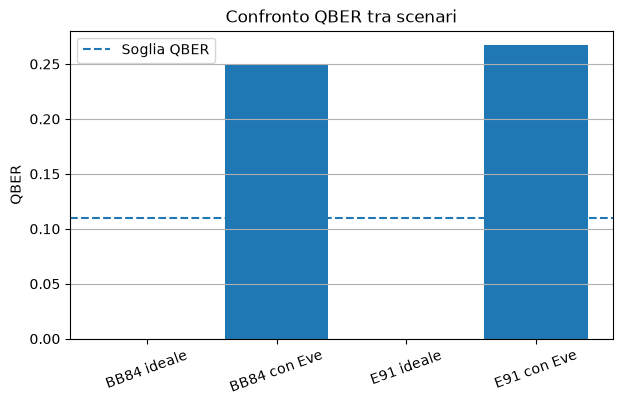

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\comparison_qber.png


In [22]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["scenario"], comparison_df["qber"])
plt.axhline(
    y=qber_threshold,
    linestyle="--",
    label="Soglia QBER",
)
plt.ylabel("QBER")
plt.title("Confronto QBER tra scenari")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()

qber_figure_path = figures_dir / "comparison_qber.png"
plt.savefig(qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_figure_path}")


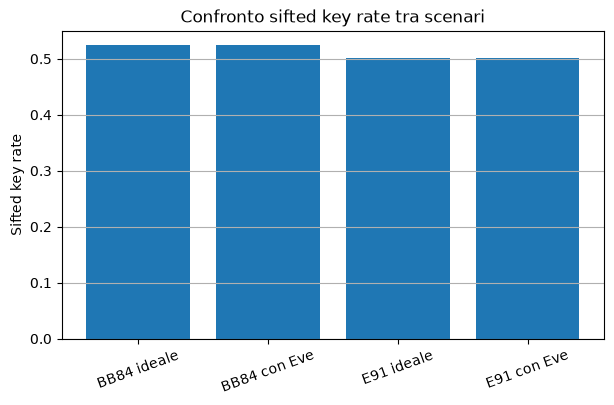

Grafico sifted key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\comparison_sifted_key_rate.png


In [23]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["scenario"], comparison_df["sifted_key_rate"])
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra scenari")
plt.xticks(rotation=20)
plt.grid(axis="y")

key_rate_figure_path = figures_dir / "comparison_sifted_key_rate.png"
plt.savefig(key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico sifted key rate salvato in: {key_rate_figure_path}")


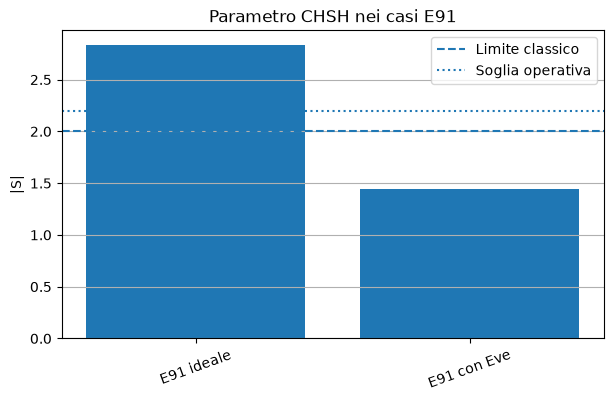

Grafico CHSH salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\comparison_chsh_e91.png


In [24]:
chsh_figure_path = figures_dir / "comparison_chsh_e91.png"

plt.figure(figsize=(7, 4))
plt.bar(chsh_comparison_df["scenario"], chsh_comparison_df["abs_S"])
plt.axhline(2, linestyle="--", label="Limite classico")
plt.axhline(chsh_security_threshold, linestyle=":", label="Soglia operativa")
plt.ylabel("|S|")
plt.title("Parametro CHSH nei casi E91")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.legend()
plt.savefig(chsh_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico CHSH salvato in: {chsh_figure_path}")


Per i grafici degli esperimenti ripetuti usiamo una tabella più semplice, perché `summary_stats` contiene colonne multi-livello.

In [25]:
repeated_plot_df = repeated_df.groupby("protocol").mean(numeric_only=True).reset_index()

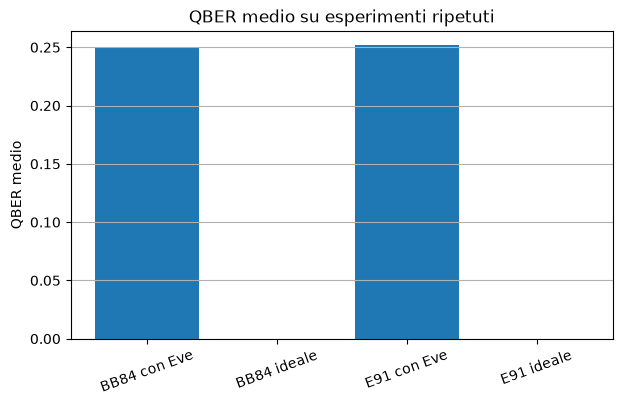

Grafico QBER medio salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\repeated_qber_mean.png


In [26]:
plt.figure(figsize=(7, 4))
plt.bar(repeated_plot_df["protocol"], repeated_plot_df["qber"])
plt.ylabel("QBER medio")
plt.title("QBER medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")

repeated_qber_figure_path = figures_dir / "repeated_qber_mean.png"
plt.savefig(repeated_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER medio salvato in: {repeated_qber_figure_path}")

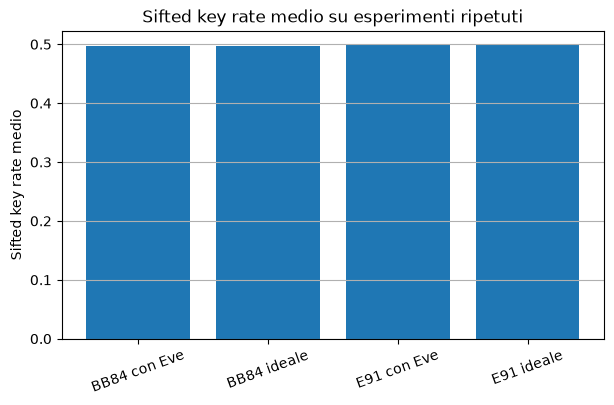

Grafico key rate medio salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\repeated_key_rate_mean.png


In [27]:
plt.figure(figsize=(7, 4))
plt.bar(repeated_plot_df["protocol"], repeated_plot_df["sifted_key_rate"])
plt.ylabel("Sifted key rate medio")
plt.title("Sifted key rate medio su esperimenti ripetuti")
plt.xticks(rotation=20)
plt.grid(axis="y")

repeated_key_rate_figure_path = figures_dir / "repeated_key_rate_mean.png"
plt.savefig(repeated_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate medio salvato in: {repeated_key_rate_figure_path}")

## Sintesi del confronto aggiornato

BB84 ideale ed E91 ideale hanno QBER circa nullo. BB84 con Eve mostra un aumento del QBER, mentre E91 con Eve mostra sia un aumento del QBER sia una degradazione di |S|.

E91 consente quindi una diagnosi pi? ricca perch? combina QBER e CHSH. BB84 ? pi? semplice dal punto di vista circuitale e sperimentale, mentre E91 ? pi? costoso perch? richiede entanglement e verifica delle correlazioni.

La decisione finale nel progetto ? semplificata e non sostituisce information reconciliation e privacy amplification. Serve per? a rendere esplicito il criterio didattico usato nel confronto: BB84 viene accettato o rifiutato in base al QBER, mentre E91 viene valutato guardando sia QBER sia robustezza della violazione CHSH.
